In [1]:
# =========================
# India GDP Prediction Project — with all graphs
# =========================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
# Step 2: Load Data
df = pd.read_excel('INDIAGDP.xlsx')


In [3]:
# Step 3: Clean Column Names
df.columns = df.columns.str.strip()
df.rename(columns={
    'Country Name': 'Country',
    'Country Code': 'Country_Code',
    'Time': 'Year',
    'Time Code': 'Year_Code',
    'GDP (current US$) [NY.GDP.MKTP.CD]': 'GDP',
    'GDP per capita (current US$) [NY.GDP.PCAP.CD]': 'GDP_per_capita',
    'GDP growth (annual %) [NY.GDP.MKTP.KD.ZG]': 'GDP_growth',
    'Imports of goods and services (% of GDP) [NE.IMP.GNFS.ZS]': 'Imports_pctGDP',
    'Exports of goods and services (% of GDP) [NE.EXP.GNFS.ZS]': 'Exports_pctGDP',
    'Total reserves (includes gold, current US$) [FI.RES.TOTL.CD]': 'Reserves',
    'Inflation, consumer prices (annual %) [FP.CPI.TOTL.ZG]': 'Inflation',
    'Population, total [SP.POP.TOTL]': 'Population',
    'Gross capital formation (% of GDP) [NE.GDI.TOTL.ZS]': 'Gross_capital_formation',
    'Industry (including construction), value added (% of GDP) [NV.IND.TOTL.ZS]': 'Industry_pctGDP',
    'Services, value added (% of GDP) [NV.SRV.TOTL.ZS]': 'Services_pctGDP'
}, inplace=True)
df.head()

,Country,Country_Code,Year,Year_Code,GDP,GDP_per_capita,GDP_growth,Imports_pctGDP,Exports_pctGDP,Reserves,Inflation,Population,Gross_capital_formation,Industry_pctGDP,Services_pctGDP
0,India,IND,1990.0,YR1990,3.209790e+11,371.085936,5.533455,8.452911,7.053350,5.637446e+09,8.971233,864972221.0,27.336198,27.453695,37.044785
1,India,IND,1991.0,YR1991,2.701053e+11,305.574056,1.056831,8.493486,8.494241,7.615987e+09,13.870246,883927600.0,25.140505,26.441720,37.785690
2,India,IND,1992.0,YR1992,2.882081e+11,319.182473,5.482396,9.590172,8.842927,9.538786e+09,11.787817,902957070.0,27.440204,26.792743,37.912568
3,India,IND,1993.0,YR1993,2.792956e+11,302.884806,4.750776,9.817322,9.834217,1.467463e+10,6.326890,922118387.0,22.716411,26.781554,38.490685
4,India,IND,1994.0,YR1994,3.272748e+11,347.734215,6.658924,10.190059,9.888085,2.422093e+10,10.247936,941163767.0,26.310167,27.628201,37.496302


In [4]:
# Step 4: Fix Year Column
df['Year'] = df['Year'].astype(str).str.replace('YR','', regex=True)
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32 entries, 0 to 31
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country                  32 non-null     object 
 1   Country_Code             32 non-null     object 
 2   Year                     32 non-null     int64  
 3   Year_Code                32 non-null     object 
 4   GDP                      32 non-null     float64
 5   GDP_per_capita           32 non-null     float64
 6   GDP_growth               32 non-null     float64
 7   Imports_pctGDP           32 non-null     float64
 8   Exports_pctGDP           32 non-null     float64
 9   Reserves                 32 non-null     float64
 10  Inflation                32 non-null     float64
 11  Population               32 non-null     float64
 12  Gross_capital_formation  32 non-null     float64
 13  Industry_pctGDP          32 non-null     float64
 14  Services_pctGDP          32 non-n

In [5]:
# Step 5: Convert numeric columns
numeric_cols = ['GDP','GDP_per_capita','GDP_growth','Imports_pctGDP','Exports_pctGDP',
                'Reserves','Inflation','Population','Gross_capital_formation',
                'Industry_pctGDP','Services_pctGDP']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df.head()

,Country,Country_Code,Year,Year_Code,GDP,GDP_per_capita,GDP_growth,Imports_pctGDP,Exports_pctGDP,Reserves,Inflation,Population,Gross_capital_formation,Industry_pctGDP,Services_pctGDP
0,India,IND,1990,YR1990,3.209790e+11,371.085936,5.533455,8.452911,7.053350,5.637446e+09,8.971233,864972221.0,27.336198,27.453695,37.044785
1,India,IND,1991,YR1991,2.701053e+11,305.574056,1.056831,8.493486,8.494241,7.615987e+09,13.870246,883927600.0,25.140505,26.441720,37.785690
2,India,IND,1992,YR1992,2.882081e+11,319.182473,5.482396,9.590172,8.842927,9.538786e+09,11.787817,902957070.0,27.440204,26.792743,37.912568
3,India,IND,1993,YR1993,2.792956e+11,302.884806,4.750776,9.817322,9.834217,1.467463e+10,6.326890,922118387.0,22.716411,26.781554,38.490685
4,India,IND,1994,YR1994,3.272748e+11,347.734215,6.658924,10.190059,9.888085,2.422093e+10,10.247936,941163767.0,26.310167,27.628201,37.496302


In [6]:
# Step 6: Feature Engineering
df['GDP_lag1'] = df['GDP'].shift(1)
df['Population_growth'] = df['Population'].pct_change()*100
df_model = df.dropna(subset=['GDP','GDP_lag1','Population_growth'])


In [7]:
# Step 7: Prepare Data and Train Model
X = df_model[['GDP_lag1','Population_growth']]
y = df_model['GDP']
model = LinearRegression()
model.fit(X, y)


LinearRegression()

In [8]:
# Step 8: Evaluate Model
y_pred = model.predict(X)
print("Training MSE:", mean_squared_error(y, y_pred))
print("Training R²:", r2_score(y, y_pred))


Training MSE: 1.373593065391e+22
Training R²: 0.9895015174984467


In [9]:
# Step 9: Predict Future GDP (2025–2030)
future_years = pd.DataFrame({'Year': np.arange(2025, 2031)})
predicted_gdp = []
last_gdp = df['GDP'].iloc[-1]
last_population = df['Population'].iloc[-1]
avg_pop_growth_rate = df['Population_growth'].tail(5).mean() / 100

for year in future_years['Year']:
    projected_population = last_population * (1 + avg_pop_growth_rate)
    pop_growth_pct = ((projected_population - last_population) / last_population) * 100
    X_future = pd.DataFrame({'GDP_lag1': [last_gdp], 'Population_growth': [pop_growth_pct]})
    gdp_pred = model.predict(X_future)[0]
    predicted_gdp.append(gdp_pred)
    last_gdp = gdp_pred
    last_population = projected_population

future_years['Predicted_GDP'] = predicted_gdp
print(future_years)

   Year  Predicted_GDP
0  2025   4.205363e+12
1  2026   4.526942e+12
2  2027   4.880279e+12
3  2028   5.268509e+12
4  2029   5.695078e+12
5  2030   6.163773e+12


In [10]:
# ============================
#   PLOT SECTIONS
# ============================


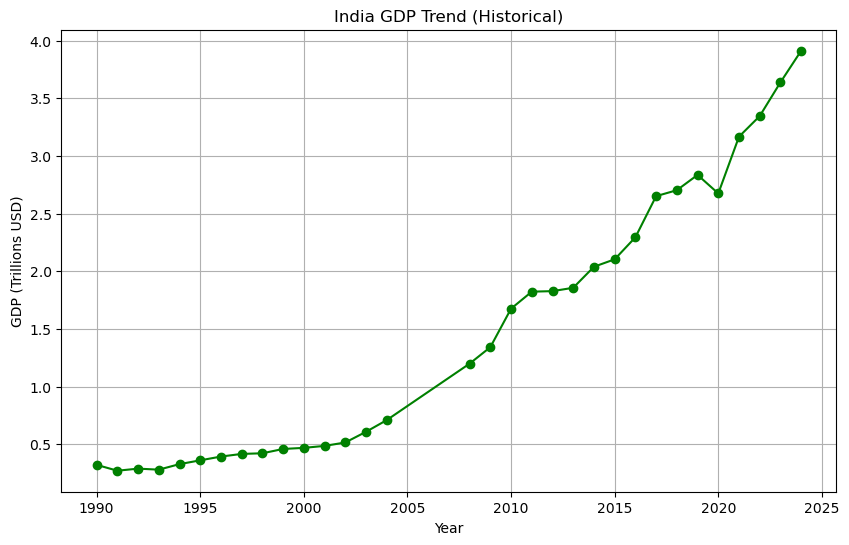

In [11]:
# GDP Trend
plt.figure(figsize=(10,6))
plt.plot(df['Year'], df['GDP']/1e12, color='green', marker='o')
plt.title('India GDP Trend (Historical)')
plt.xlabel('Year')
plt.ylabel('GDP (Trillions USD)')
plt.grid(True)
plt.savefig('1_GDP_Trend.png')
plt.show()

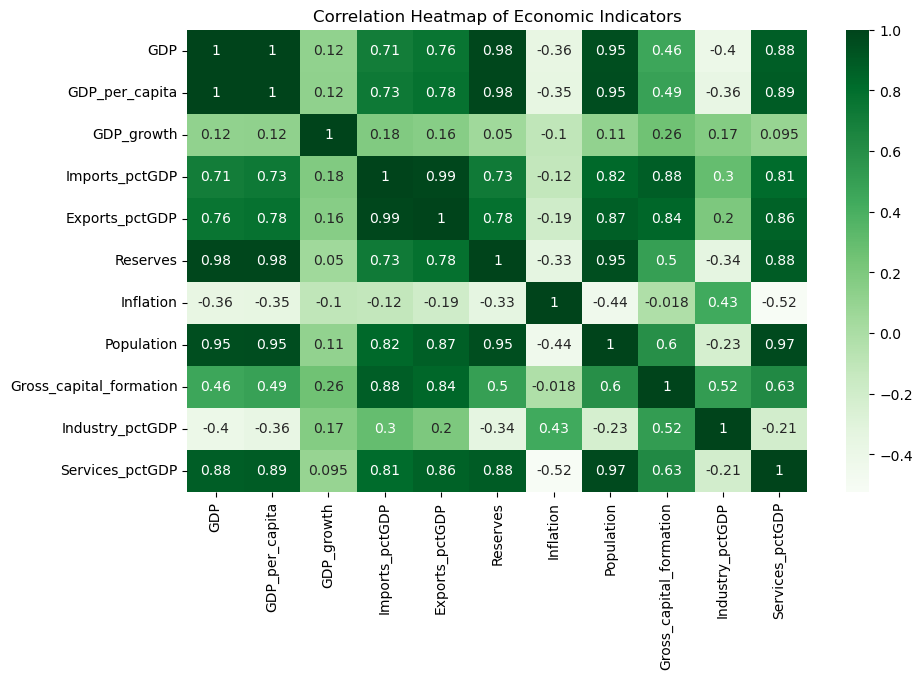

In [17]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), cmap='Greens', annot=True)
plt.title('Correlation Heatmap of Economic Indicators')
plt.savefig('2_Correlation_Heatmap.png')
plt.show()

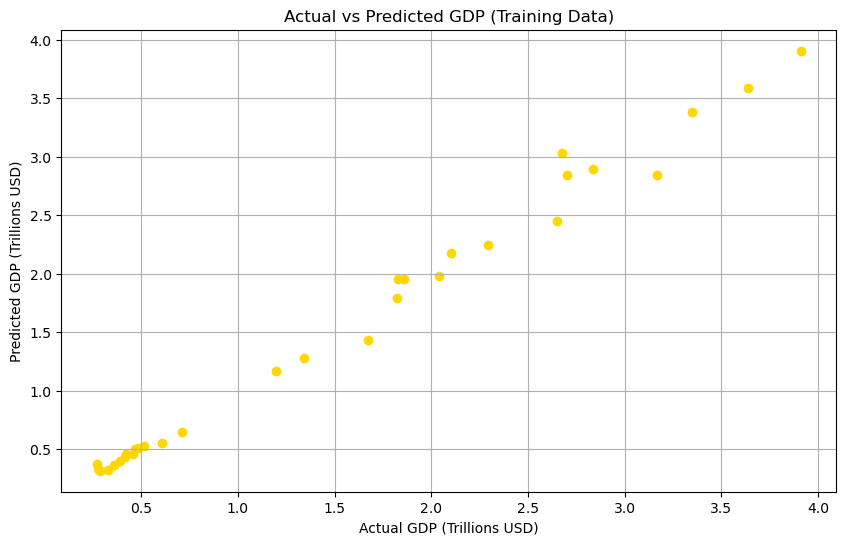

In [12]:
#  Actual vs Predicted (Training)
plt.figure(figsize=(10,6))
plt.scatter(y/1e12, y_pred/1e12, color='gold')
plt.xlabel('Actual GDP (Trillions USD)')
plt.ylabel('Predicted GDP (Trillions USD)')
plt.title('Actual vs Predicted GDP (Training Data)')
plt.grid(True)
plt.savefig('3_Actual_vs_Predicted.png')
plt.show()

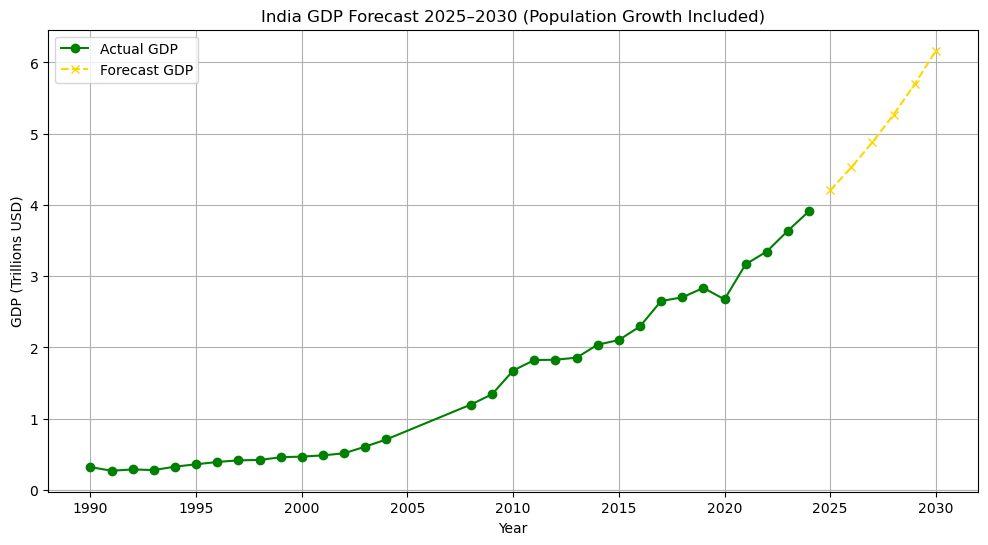

In [13]:
#  GDP Forecast (2025–2030)
plt.figure(figsize=(12,6))
plt.plot(df['Year'], df['GDP']/1e12, label='Actual GDP', color='green', marker='o')
plt.plot(future_years['Year'], future_years['Predicted_GDP']/1e12, label='Forecast GDP', color='gold', marker='x', linestyle='--')
plt.xlabel('Year')
plt.ylabel('GDP (Trillions USD)')
plt.title('India GDP Forecast 2025–2030 (Population Growth Included)')
plt.legend()
plt.grid(True)
plt.savefig('4_GDP_Forecast.png')
plt.show()